## The Curse of Dimensionality

- Many real-world ML problems involve (if not millions) thousands of features.

- Fortunately the many features of an ML problem can be reduced into considerable fewer features

In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784')
mnist

X, y = mnist["data"], mnist["target"]
X.shape

(70000, 784)

## Projection

Involves squashing by projecting onto a plane

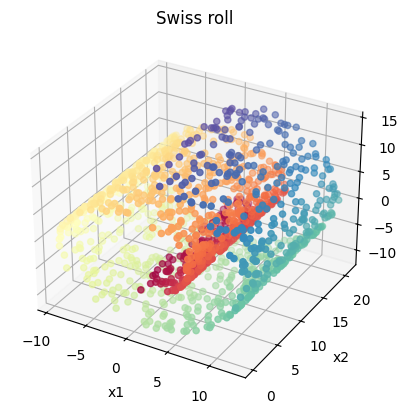

In [ ]:
from sklearn import datasets
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

X, color = datasets.make_swiss_roll(n_samples=1500)

x1 = X[:,0]
x2 = X[:,1]
x3 = X[:,2]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x1, x2, x3, c=color, cmap=plt.cm.Spectral)

ax.set_title("Swiss roll")
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')

plt.show()

## Manifold learning

Unrolls data based on local resemblance.

## Principal Component Analysis(PCA)

Main idea:
1.   Determine the hyperplane that lies closest to the dataset;
2.   Project the dataset into the hyperplane


We then select the hyperplane that preserves the greatest number of variance.

PCA basically aims to find the axis(or hyperplane) that preserves the maximum variance for which to project the original dataset.


## Singular Value Decomposition (SVD) Matrix

SVD allows us to find the PCs.

$$X = U \cdot \Sigma \cdot V^T$$

where

$$V = \begin{pmatrix} c_1 & c_2 & \dots & c_n \end{pmatrix}$$

In [ ]:
import numpy as np

x1 = 2 * np.random.rand(100, 1) # generate linear random data
x2 = 4 + 4 * x1 + np.random.randn(100, 1)
x3 = x1**2 + x2**2

X = np.c_[x1, x2, x3]

X_centered = X - X.mean(axis=0) # it is necessary to centre the dataset when using PCA
U, s, V = np.linalg.svd(X_centered)
c1 = V.T[:, 0]
c2 = V.T[:, 1]

## Projecting Down to d Dimensions

W2: This variable W2 (often called the 'projection matrix' or 'transformation matrix') now holds these first two principal components as its columns. It's a matrix that will transform your original 3D data into a 2D representation.

These two lines of code select the top two principal components (from V.T) and then use them to project the X_centered 3D data down into a new 2D space (X2D), losing the least amount of variance possible during this dimensionality reduction.

In [ ]:
W2 = V.T[:, :2]
X2D = X_centered.dot(W2)

## Projection via fit_transform() Method

The PCA class in scikit-learn already implements the PCA using
SVD decomposition.

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
X2D = pca.fit_transform(X)

In [ ]:
pca.components_

array([[ 0.01018161,  0.05609574,  0.99837348],
       [ 0.28418556,  0.95709277, -0.05667448]])

## Explained Variance Ratio

Quantifies the proportion of the dataset's variance that lies along the axis of each PC.


Text(0.5, 0, 'x3')

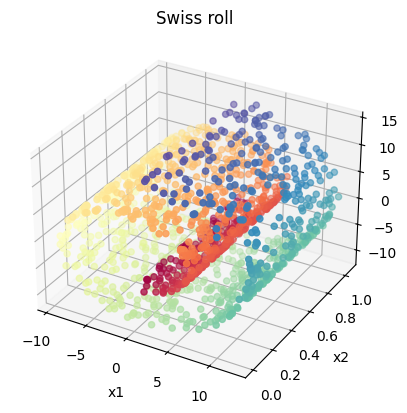

In [ ]:
from sklearn import datasets
from sklearn.decomposition import PCA

X, color = datasets.make_swiss_roll(n_samples=1500)

X[:, 1] *= 0.05 # make the Swiss-roll thinner

x1 = X[:, 0]
x2 = X[:, 1]
x3 = X[:, 2]


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x1, x2, x3, c=color, cmap=plt.cm.Spectral)

ax.set_title("Swiss roll")
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')

In [ ]:
# Compute PCA
pca = PCA(n_components = 3)
X3D = pca.fit_transform(X)

pca.explained_variance_ratio_

array([0.56734638, 0.43167757, 0.00097605])

* 1st PC accounts for 56% of total variance;
* 2nd PC accounts for 43% of total variance;
* 3rd PC accounts for only 0.1% of total variance.

## Choosing the Right Number of Dimensions

Ideal strategy is to choose the number of dimensions that adds up to a sufficiently significant portion of the variance(e.g., 95%)

In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784')
X, y = mnist['data'], mnist['target']
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]
pca = PCA()
pca.fit(X_train)

PCA()

In [ ]:
# get the cummulative sum array of each principal component
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1

In [ ]:
pca = PCA(n_components=d)
X_reduced = pca.fit_transform(X_train)

n_components=0.95 specifies the overall variance
proportion of the PCs to consider.


In [ ]:
# using exact figure
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_train)

plot the explained variance as a function
of the number of dimensions

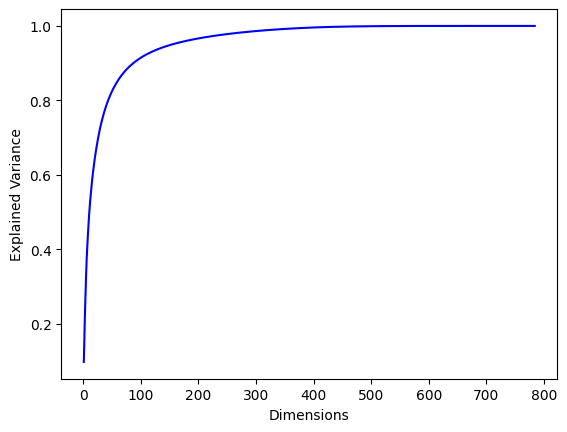

In [ ]:
cumsum = cumsum.reshape(-1, 1) #reshape to column vector
X_new = np.linspace(1, len(cumsum), num=len(cumsum)).reshape(-1, 1)
plt.ylabel('Explained Variance')
plt.xlabel('Dimensions')
plt.plot(X_new, cumsum, 'b-')

At approx. 150, the graph has an elbow where explained variance growth rate slows
down.

## PCA for Compression

An application to facial image compression.

In [ ]:
from sklearn.datasets import fetch_olivetti_faces
oliv = fetch_olivetti_faces()
print(oliv.keys())

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
dict_keys(['data', 'images', 'target', 'DESCR'])


In [ ]:
print(oliv.data.shape, oliv.target.shape)

(400, 4096) (400,)


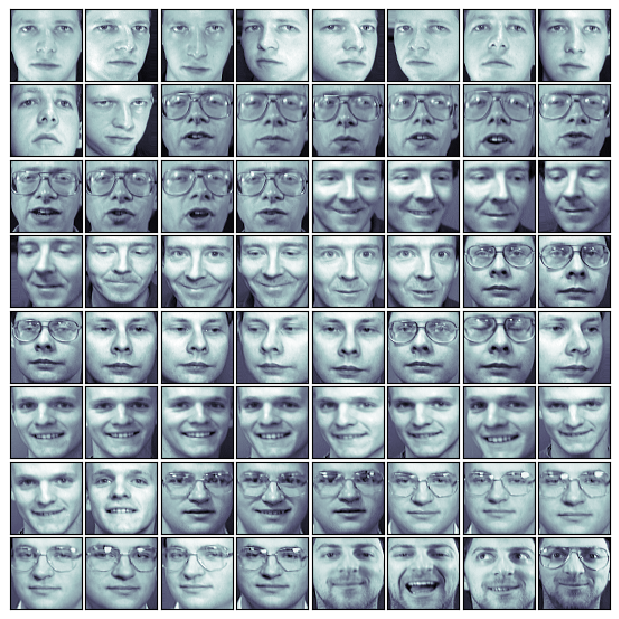

In [ ]:
# Setup up a figure 6 inches by 6 inches
fig = plt.figure(figsize=(6,6))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

# plot the faces, each image is 64 by 64 pixels
for i in range(64):
  ax = fig.add_subplot(8, 8, i+1, xticks=[], yticks=[])
  ax.imshow(oliv.images[i], cmap=plt.cm.bone, interpolation='nearest')

### Reduce number of dimensions

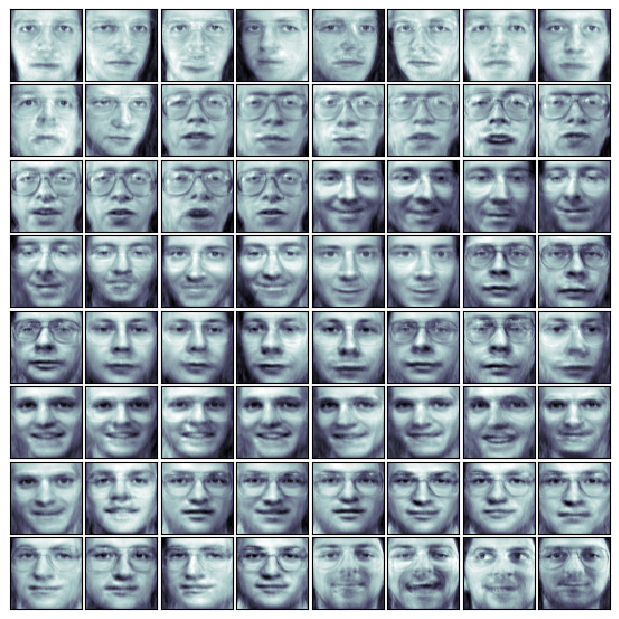

In [ ]:
from sklearn.decomposition import PCA

X, y = oliv.data, oliv.target
pca_oliv = PCA(64)
X_proj = pca_oliv.fit_transform(X)

# get inverse transform then reshape
X_inv_proj = pca_oliv.inverse_transform(X_proj)
X_proj_img = np.reshape(X_inv_proj, (400, 64, 64))

# plot the images
fig = plt.figure(figsize=(6,6))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for i in range(64):
  ax = fig.add_subplot(8, 8, i+1, xticks=[], yticks=[])
  ax.imshow(X_proj_img[i], cmap=plt.cm.bone, interpolation='nearest')



## Incremental PCA

Through IPCA, the training set can be split into mini-batches
and fed into the IPCA algorithms one-mini batch per each
time.

In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784')
X, y = mnist['data'], mnist['target']
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

partial_fit() must be used for each mini-batch and not fit() (which is for
the whole training set)."

In [ ]:
from sklearn.decomposition import IncrementalPCA

n_batches = 100
inc_pca = IncrementalPCA(n_components=154)

for X_batch in np.array_split(X_train, n_batches):
  inc_pca.partial_fit(X_batch)

X_reduced = inc_pca.transform(X_train) # reduce down to 154 dimensions.

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


## Randomised PCA

Randomised PCA is a stochastic algorithm which can quickly find
an approximation of the first d principal components

The computational complexity of Randomised PCA is $O(m \times d^2) + O(d^3)$, whereas the complexity of previous standard algorithms is $O(m \times n^2) + O(n^3)$

In [ ]:
rnd_pca = PCA(n_components=154, svd_solver="randomized")
X_reduced = rnd_pca.fit_transform(X_train)